# RetailMind AI — 02: Exploratory Data Analysis (EDA)

**Purpose:** Discover patterns in the retail transaction data.

**Question answered:** *What patterns exist in this retail dataset?*

> All charts are saved to `../outputs/figures/`  
> Data quality validation is in `01_data_understanding.ipynb`


## 1. Imports, Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Style ──
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'     : 120,
    'figure.figsize' : (12, 5),
    'axes.titlesize' : 14,
    'axes.labelsize' : 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# ── Output directory ──
FIGURES_DIR = '../outputs/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Libraries loaded. Figures will be saved to:", os.path.abspath(FIGURES_DIR))


Libraries loaded. Figures will be saved to: d:\RetailMindAI\RetailMindAI\outputs\figures


In [2]:
# ── Load raw dataset — do NOT modify this file ──
DATA_PATH = '../data/raw/Amazon.csv'
df = pd.read_csv(DATA_PATH)

# Parse OrderDate (already validated in notebook 01)
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)


Loaded: 100,000 rows × 20 columns


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908


---
## 2. Order Status Analysis

Understand the distribution of order outcomes across the dataset.


In [3]:
# ── Calculate order status counts and percentages ──
status_counts = df['OrderStatus'].value_counts().reset_index()
status_counts.columns = ['OrderStatus', 'Count']
status_counts['Percentage'] = (status_counts['Count'] / len(df) * 100).round(2)
status_counts['Percentage_Label'] = status_counts['Percentage'].astype(str) + '%'

print("=== Order Status Distribution ===")
print(status_counts.to_string(index=False))


=== Order Status Distribution ===
OrderStatus  Count  Percentage Percentage_Label
  Delivered  74628       74.63           74.63%
    Shipped  15192       15.19           15.19%
    Pending   4103        4.10             4.1%
   Returned   3049        3.05            3.05%
  Cancelled   3028        3.03            3.03%


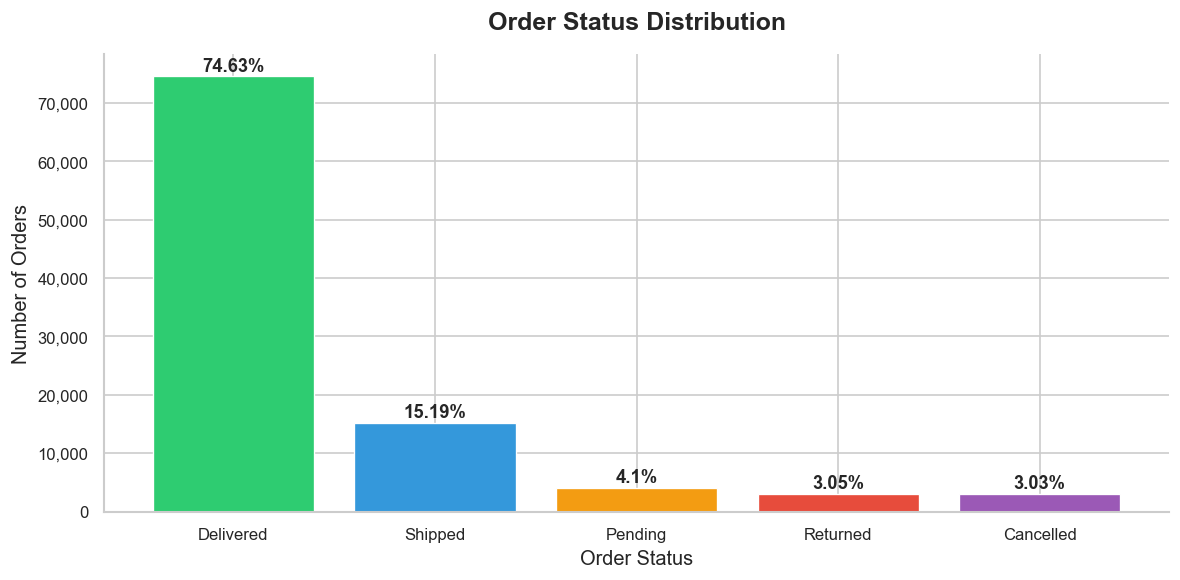

Saved: ../outputs/figures\order_status_distribution.png


In [4]:
# ── Bar chart ──
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6']
bars = ax.bar(status_counts['OrderStatus'], status_counts['Count'],
              color=colors[:len(status_counts)], edgecolor='white', linewidth=0.8)

for bar, pct in zip(bars, status_counts['Percentage']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Order Status Distribution', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Order Status')
ax.set_ylabel('Number of Orders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

save_path = os.path.join(FIGURES_DIR, 'order_status_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


---
## 3. Sales & Order Trend Analysis

Extract temporal features to understand how orders and revenue evolve over time.

> ⚠️ These date features are created **temporarily for EDA only** — they are not persisted back to the raw file.


In [5]:
# ── Temporary date features for EDA ──
df['Year']      = df['OrderDate'].dt.year
df['Month']     = df['OrderDate'].dt.month
df['MonthName'] = df['OrderDate'].dt.strftime('%b')   # Jan, Feb, ...

print("Temporary date features added: Year, Month, MonthName")
print(df[['OrderDate', 'Year', 'Month', 'MonthName']].head(3))


Temporary date features added: Year, Month, MonthName
   OrderDate  Year  Month MonthName
0 2023-01-31  2023      1       Jan
1 2023-12-30  2023     12       Dec
2 2022-05-10  2022      5       May


In [6]:
# ── Orders by Year ──
orders_by_year = df.groupby('Year')['OrderID'].count().reset_index()
orders_by_year.columns = ['Year', 'OrderCount']

revenue_by_year = df.groupby('Year')['TotalAmount'].sum().reset_index()
revenue_by_year.columns = ['Year', 'Revenue']

print("=== Orders by Year ===")
print(orders_by_year)
print()
print("=== Revenue by Year ===")
print(revenue_by_year)


=== Orders by Year ===
   Year  OrderCount
0  2020       20066
1  2021       19890
2  2022       20078
3  2023       20096
4  2024       19870

=== Revenue by Year ===
   Year      Revenue
0  2020  18529864.02
1  2021  18248574.81
2  2022  18367248.41
3  2023  18513912.19
4  2024  18166048.49


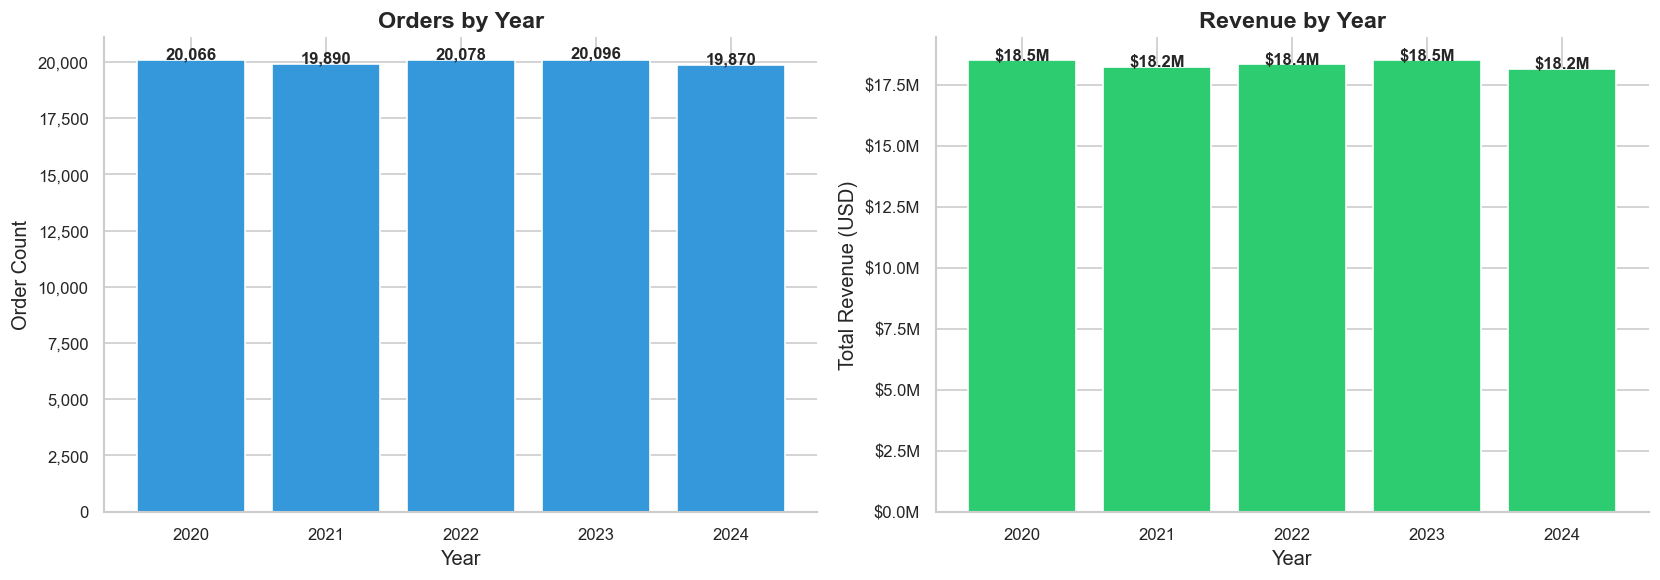

Saved: ../outputs/figures\trends_orders_revenue_by_year.png


In [7]:
# ── Chart: Orders & Revenue by Year ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orders
axes[0].bar(orders_by_year['Year'].astype(str), orders_by_year['OrderCount'],
            color='#3498db', edgecolor='white')
for bar, val in zip(axes[0].patches, orders_by_year['OrderCount']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Orders by Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Order Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Revenue
axes[1].bar(revenue_by_year['Year'].astype(str), revenue_by_year['Revenue'],
            color='#2ecc71', edgecolor='white')
for bar, val in zip(axes[1].patches, revenue_by_year['Revenue']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'${val/1e6:.1f}M', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Revenue by Year', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Revenue (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'trends_orders_revenue_by_year.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


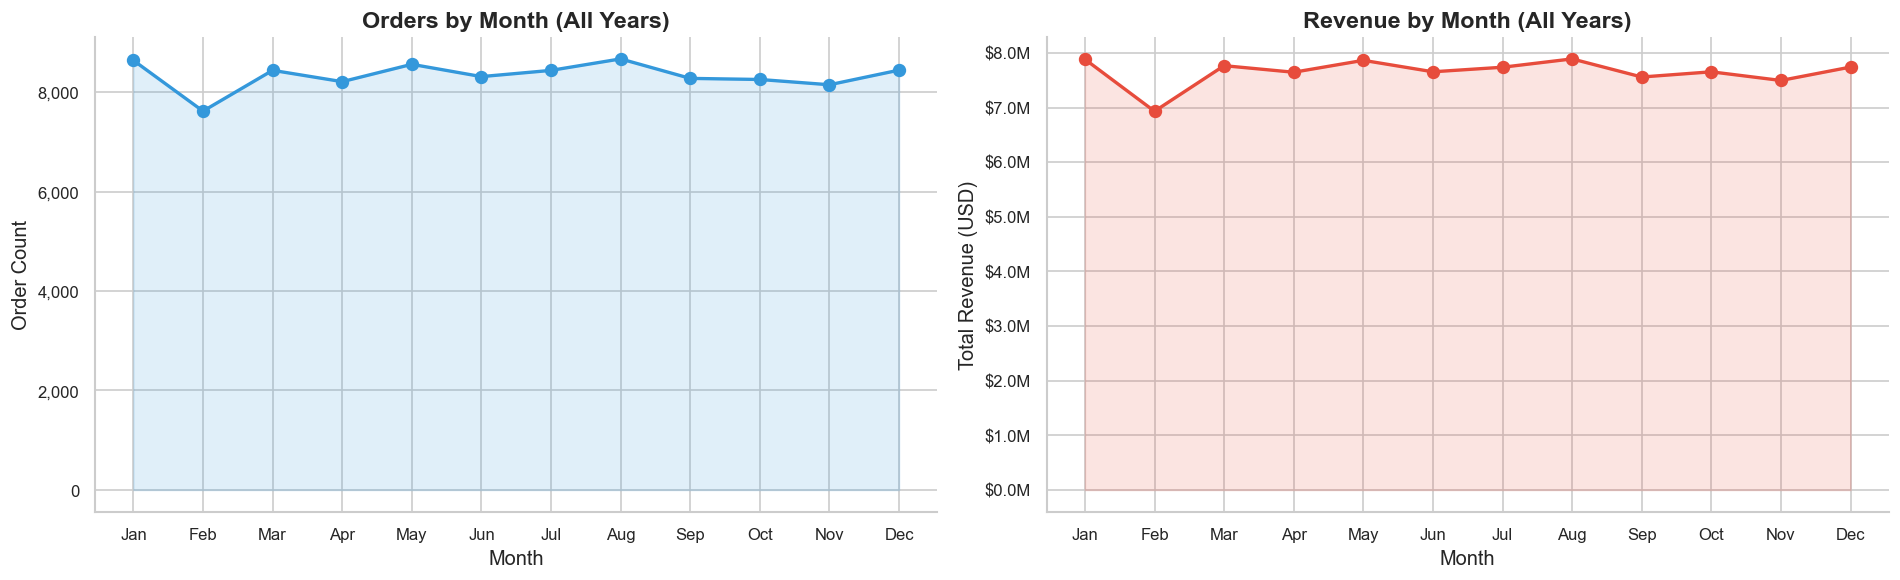

Saved: ../outputs/figures\trends_orders_revenue_by_month.png


In [8]:
# ── Orders by Month (all years combined) ──
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

orders_by_month = (df.groupby(['Month', 'MonthName'])['OrderID']
                    .count().reset_index()
                    .sort_values('Month'))
orders_by_month.columns = ['Month', 'MonthName', 'OrderCount']

revenue_by_month = (df.groupby(['Month', 'MonthName'])['TotalAmount']
                     .sum().reset_index()
                     .sort_values('Month'))
revenue_by_month.columns = ['Month', 'MonthName', 'Revenue']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(orders_by_month['MonthName'], orders_by_month['OrderCount'],
             marker='o', color='#3498db', linewidth=2, markersize=7)
axes[0].fill_between(range(len(orders_by_month)), orders_by_month['OrderCount'],
                     alpha=0.15, color='#3498db')
axes[0].set_xticks(range(len(orders_by_month)))
axes[0].set_xticklabels(orders_by_month['MonthName'])
axes[0].set_title('Orders by Month (All Years)', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Order Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].plot(revenue_by_month['MonthName'], revenue_by_month['Revenue'],
             marker='o', color='#e74c3c', linewidth=2, markersize=7)
axes[1].fill_between(range(len(revenue_by_month)), revenue_by_month['Revenue'],
                     alpha=0.15, color='#e74c3c')
axes[1].set_xticks(range(len(revenue_by_month)))
axes[1].set_xticklabels(revenue_by_month['MonthName'])
axes[1].set_title('Revenue by Month (All Years)', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Revenue (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'trends_orders_revenue_by_month.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


---
## 4. Product Analysis

Identify the top-performing products by quantity sold, revenue generated, and order count.


In [9]:
# ── Build product summary ──
product_summary = (
    df.groupby(['ProductID', 'ProductName', 'Category', 'Brand'])
    .agg(
        Total_Quantity = ('Quantity',    'sum'),
        Total_Revenue  = ('TotalAmount', 'sum'),
        Order_Count    = ('OrderID',     'count')
    )
    .reset_index()
    .sort_values('Total_Revenue', ascending=False)
)

print(f"Total distinct products: {len(product_summary)}")
product_summary.head(10)


Total distinct products: 3000


,ProductID,ProductName,Category,Brand,Total_Quantity,Total_Revenue,Order_Count
1995,P00034,Desk Organizer,Clothing,KiddoFun,166,58059.53,58
1660,P00028,Jeans,Sports & Outdoors,Apex,156,56329.85,50
2794,P00047,Memory Card 128GB,Home & Kitchen,HomeEase,162,55874.05,53
1325,P00023,Cookware Set,Books,KiddoFun,147,53889.96,43
2549,P00043,HDMI Cable 2m,Electronics,Zenith,154,53200.52,48
1120,P00019,LED Desk Lamp,Sports & Outdoors,Apex,167,52494.29,52
467,P00008,4K Monitor,Sports & Outdoors,ReadMore,181,52452.39,59
229,P00004,USB-C Charger,Sports & Outdoors,Zenith,141,52155.04,47
394,P00007,Mechanical Keyboard,Home & Kitchen,HomeEase,144,51373.57,43
1132,P00019,LED Desk Lamp,Toys & Games,CoreTech,155,51046.67,43


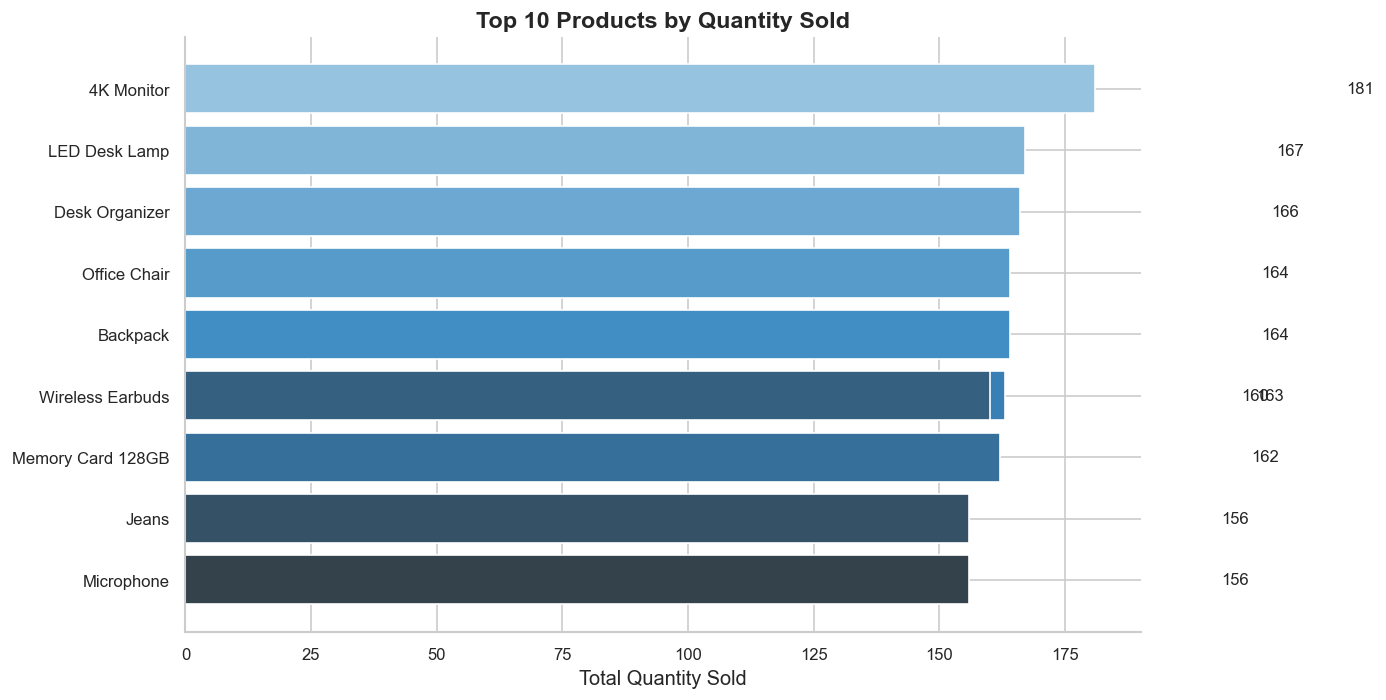

Saved: ../outputs/figures\top_products_quantity.png


In [10]:
# ── Top 10 by Quantity ──
top_qty = product_summary.nlargest(10, 'Total_Quantity')

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Blues_d', 10)
bars = ax.barh(top_qty['ProductName'], top_qty['Total_Quantity'],
               color=colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=10)
ax.set_title('Top 10 Products by Quantity Sold', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Quantity Sold')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'top_products_quantity.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


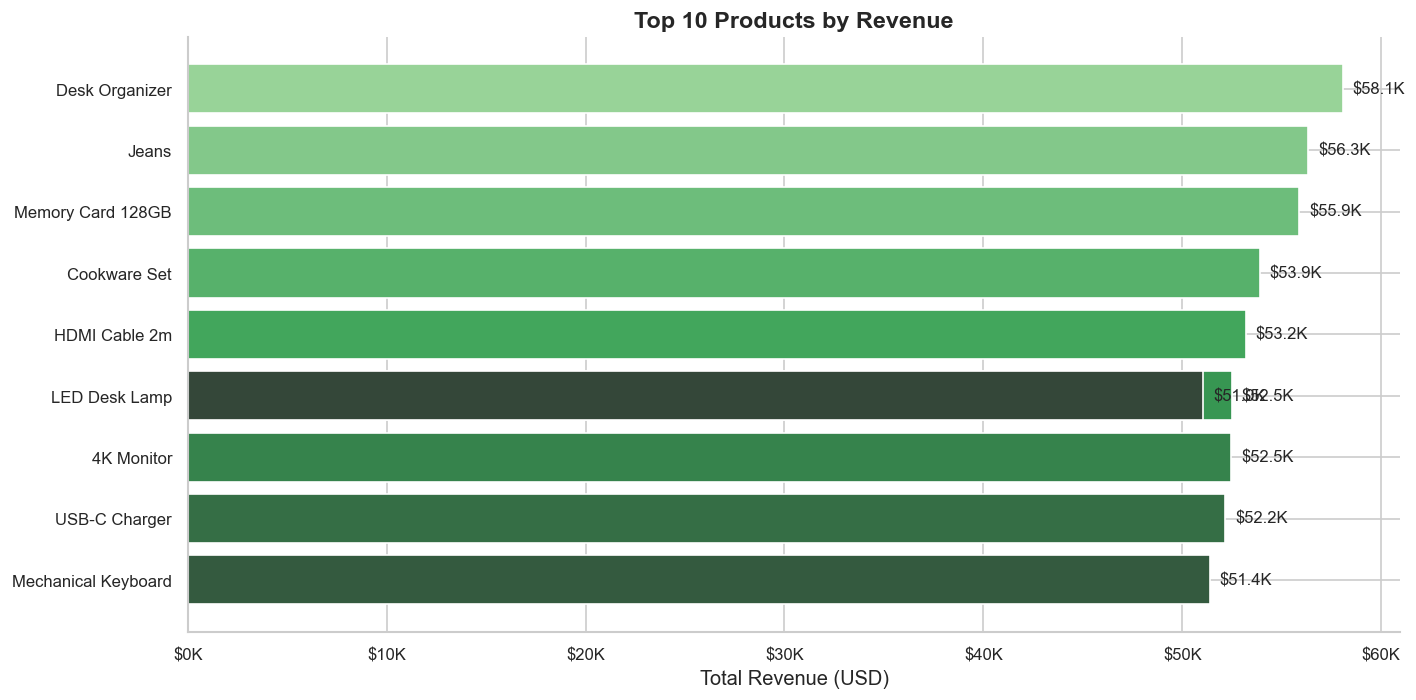

Saved: ../outputs/figures\top_products_revenue.png


In [11]:
# ── Top 10 by Revenue ──
top_rev = product_summary.nlargest(10, 'Total_Revenue')

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Greens_d', 10)
bars = ax.barh(top_rev['ProductName'], top_rev['Total_Revenue'],
               color=colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width()/1000:.1f}K', va='center', fontsize=10)
ax.set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'top_products_revenue.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


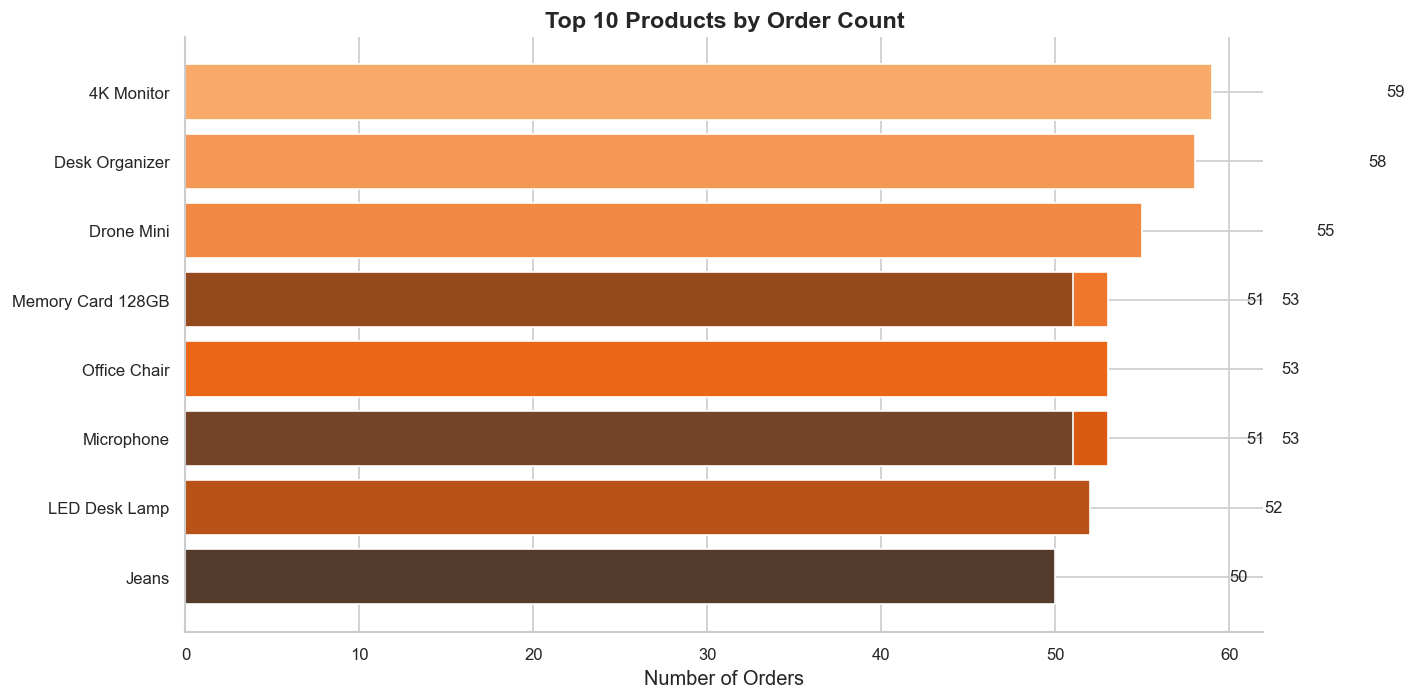

Saved: ../outputs/figures\top_products_orders.png


In [12]:
# ── Top 10 by Order Count ──
top_orders = product_summary.nlargest(10, 'Order_Count')

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Oranges_d', 10)
bars = ax.barh(top_orders['ProductName'], top_orders['Order_Count'],
               color=colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=10)
ax.set_title('Top 10 Products by Order Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'top_products_orders.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


---
## 5. Category Analysis


In [13]:
# ── Category Summary ──
cat_summary = (
    df.groupby('Category')
    .agg(
        Order_Count    = ('OrderID',     'count'),
        Total_Quantity = ('Quantity',    'sum'),
        Total_Revenue  = ('TotalAmount', 'sum')
    )
    .reset_index()
    .sort_values('Total_Revenue', ascending=False)
)
cat_summary['Revenue_Pct'] = (cat_summary['Total_Revenue'] / cat_summary['Total_Revenue'].sum() * 100).round(2)

print("=== Category Summary ===")
cat_summary


=== Category Summary ===


,Category,Order_Count,Total_Quantity,Total_Revenue,Revenue_Pct
2,Electronics,16853,50696,15584217.18,16.97
4,Sports & Outdoors,16804,50543,15345571.88,16.71
0,Books,16752,49981,15261837.01,16.62
1,Clothing,16439,49523,15253397.50,16.61
5,Toys & Games,16542,49773,15216684.99,16.57
3,Home & Kitchen,16610,49624,15163939.36,16.51


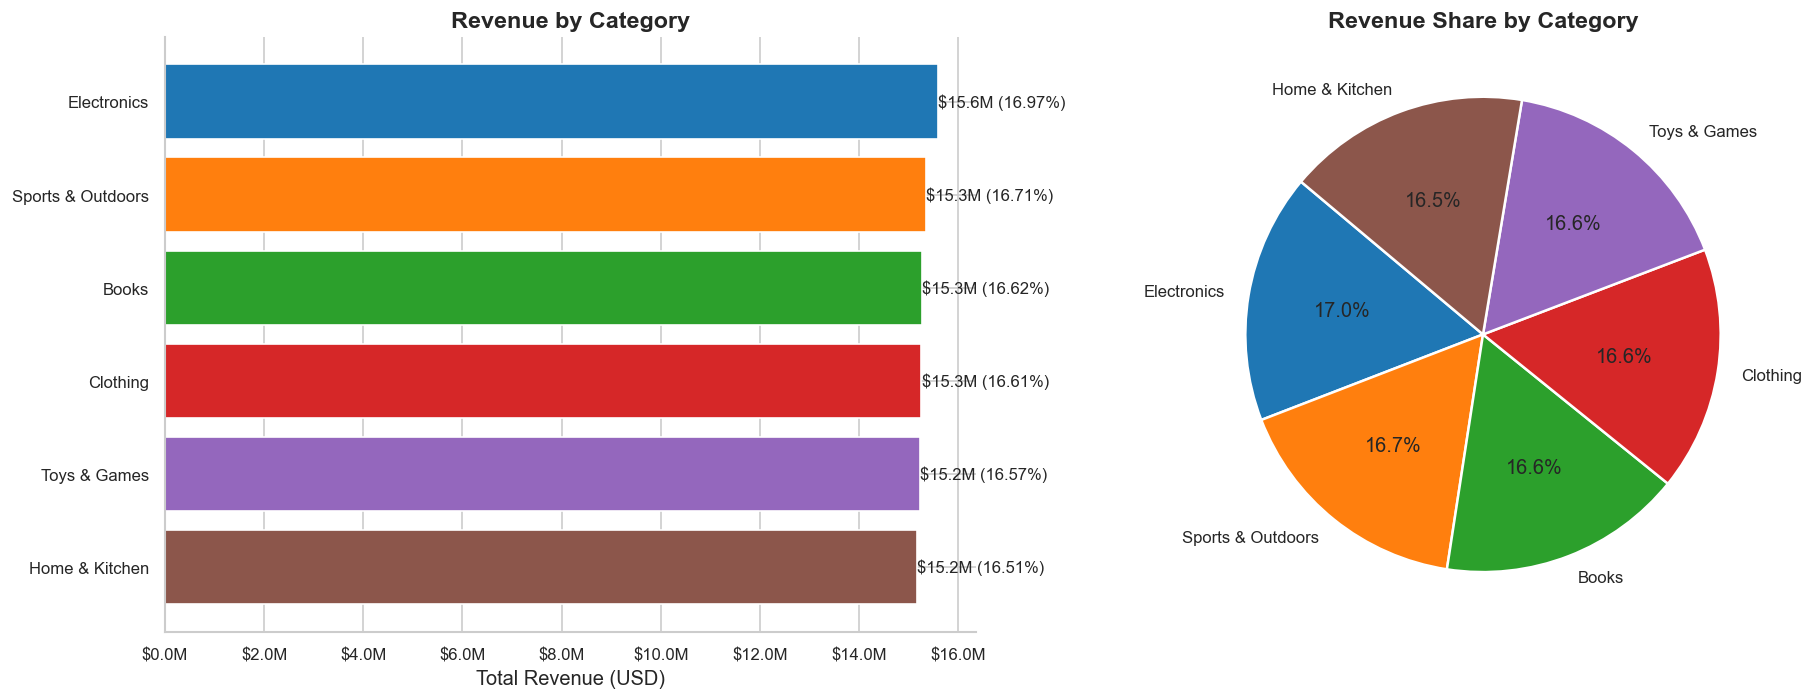

Saved: ../outputs/figures\revenue_by_category.png


In [14]:
# ── Revenue by Category chart ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
palette = sns.color_palette('tab10', len(cat_summary))
axes[0].barh(cat_summary['Category'], cat_summary['Total_Revenue'],
             color=palette, edgecolor='white')
for i, (val, pct) in enumerate(zip(cat_summary['Total_Revenue'], cat_summary['Revenue_Pct'])):
    axes[0].text(val + 5000, i, f'${val/1e6:.1f}M ({pct}%)', va='center', fontsize=10)
axes[0].set_title('Revenue by Category', fontweight='bold')
axes[0].set_xlabel('Total Revenue (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].invert_yaxis()

# Pie chart
wedge_props = {'linewidth': 1.5, 'edgecolor': 'white'}
axes[1].pie(cat_summary['Total_Revenue'], labels=cat_summary['Category'],
            autopct='%1.1f%%', colors=palette,
            wedgeprops=wedge_props, startangle=140)
axes[1].set_title('Revenue Share by Category', fontweight='bold')

sns.despine(ax=axes[0])
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'revenue_by_category.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


---
## 6. Brand Analysis


In [15]:
# ── Brand Summary ──
brand_summary = (
    df.groupby('Brand')
    .agg(
        Order_Count    = ('OrderID',     'count'),
        Total_Quantity = ('Quantity',    'sum'),
        Total_Revenue  = ('TotalAmount', 'sum')
    )
    .reset_index()
    .sort_values('Total_Revenue', ascending=False)
)
brand_summary['Revenue_Pct'] = (brand_summary['Total_Revenue'] / brand_summary['Total_Revenue'].sum() * 100).round(2)

print("=== Brand Summary ===")
brand_summary


=== Brand Summary ===


,Brand,Order_Count,Total_Quantity,Total_Revenue,Revenue_Pct
2,CoreTech,10127,30430,9343720.59,10.18
5,KiddoFun,10077,30168,9324749.55,10.15
7,ReadMore,10204,30421,9278406.63,10.10
8,UrbanStyle,9854,30104,9249027.45,10.07
9,Zenith,9990,30058,9239960.39,10.06
0,Apex,9937,29955,9147604.72,9.96
6,NexPro,9962,29791,9078824.97,9.89
3,FitLife,10147,30121,9061444.68,9.87
1,BrightLux,9907,29616,9056816.11,9.86
4,HomeEase,9795,29476,9045092.83,9.85


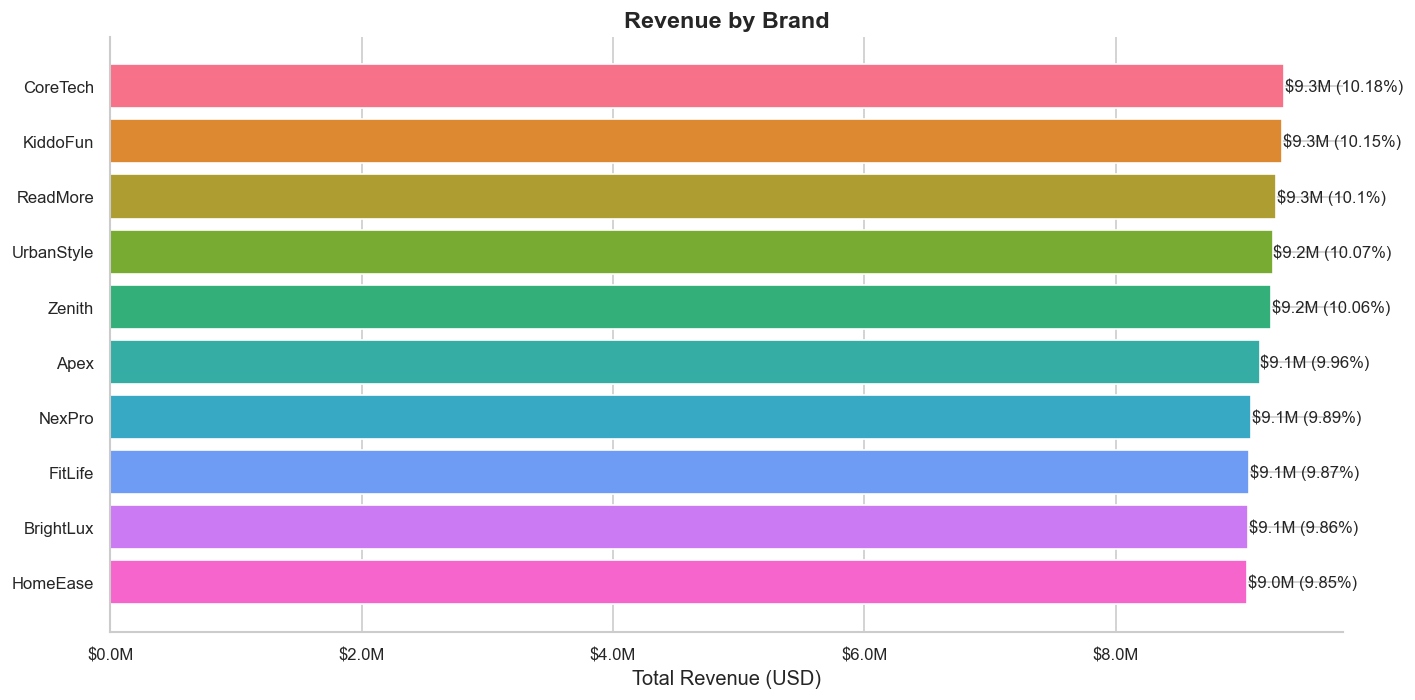

Saved: ../outputs/figures\revenue_by_brand.png


In [16]:
# ── Revenue by Brand chart ──
fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette('husl', len(brand_summary))
bars = ax.barh(brand_summary['Brand'], brand_summary['Total_Revenue'],
               color=palette, edgecolor='white')
for bar, pct in zip(bars, brand_summary['Revenue_Pct']):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width()/1e6:.1f}M ({pct}%)', va='center', fontsize=10)
ax.set_title('Revenue by Brand', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'revenue_by_brand.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


---
## 7. Customer Analysis

> ⚠️ This section performs **basic behavioral analysis only**.  
> RFM scoring and K-Means segmentation will be done in a later phase.


In [17]:
# ── Customer-level aggregation ──
customer_summary = (
    df.groupby('CustomerID')
    .agg(
        Order_Count    = ('OrderID',     'count'),
        Total_Quantity = ('Quantity',    'sum'),
        Total_Revenue  = ('TotalAmount', 'sum'),
    )
    .reset_index()
)
customer_summary['Avg_Order_Value'] = (customer_summary['Total_Revenue'] / customer_summary['Order_Count']).round(2)

print("=== Customer Summary Stats ===")
print(customer_summary[['Order_Count','Total_Quantity','Total_Revenue','Avg_Order_Value']].describe().round(2))


=== Customer Summary Stats ===
       Order_Count  Total_Quantity  Total_Revenue  Avg_Order_Value
count     43233.00        43233.00       43233.00         43233.00
mean          2.31            6.94        2123.97           918.46
std           1.26            4.35        1594.38           551.59
min           1.00            1.00           6.19             6.19
25%           1.00            4.00         876.19           508.94
50%           2.00            6.00        1805.41           837.09
75%           3.00            9.00        2992.43          1226.15
max          10.00           35.00       15215.79          3484.44


In [18]:
# ── Top 10 by Revenue ──
print("=== Top 10 Customers by Revenue ===")
top_rev_customers = customer_summary.nlargest(10, 'Total_Revenue')[
    ['CustomerID','Order_Count','Total_Revenue','Avg_Order_Value']
]
top_rev_customers['Total_Revenue'] = top_rev_customers['Total_Revenue'].round(2)
print(top_rev_customers.to_string(index=False))

print()
print("=== Top 10 Customers by Order Count ===")
top_order_customers = customer_summary.nlargest(10, 'Order_Count')[
    ['CustomerID','Order_Count','Total_Revenue','Avg_Order_Value']
]
print(top_order_customers.to_string(index=False))


=== Top 10 Customers by Revenue ===
CustomerID  Order_Count  Total_Revenue  Avg_Order_Value
CUST023748           10       15215.79          1521.58
CUST009614            9       12160.96          1351.22
CUST034178            6       11418.88          1903.15
CUST001153            9       11282.96          1253.66
CUST004883            5       11214.44          2242.89
CUST000787            7       10962.32          1566.05
CUST015677            5       10956.10          2191.22
CUST042689            8       10726.80          1340.85
CUST015231            6       10638.79          1773.13
CUST033270            5       10593.41          2118.68

=== Top 10 Customers by Order Count ===
CustomerID  Order_Count  Total_Revenue  Avg_Order_Value
CUST023748           10       15215.79          1521.58
CUST037103           10        7467.53           746.75
CUST001153            9       11282.96          1253.66
CUST003244            9        7337.37           815.26
CUST005654            9    

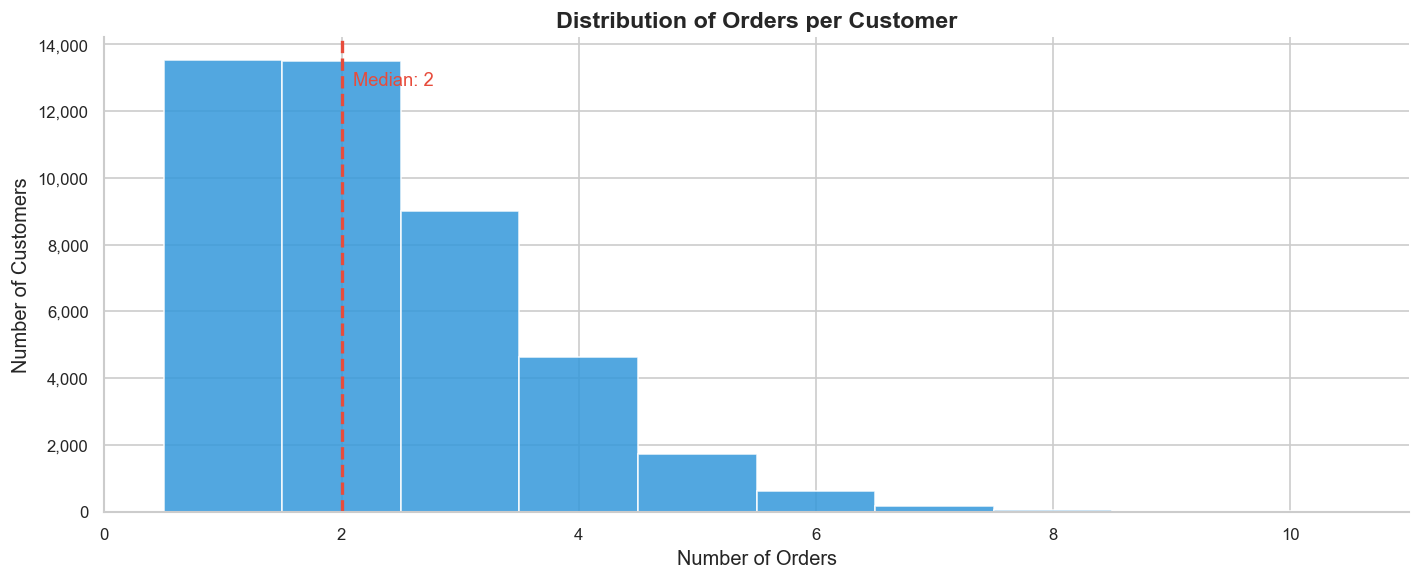

Saved: ../outputs/figures\customer_order_distribution.png


In [19]:
# ── Customer Order Distribution chart ──
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(customer_summary['Order_Count'], bins=range(1, customer_summary['Order_Count'].max() + 2),
        color='#3498db', edgecolor='white', alpha=0.85, align='left')
ax.set_title('Distribution of Orders per Customer', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Annotate median
median_orders = customer_summary['Order_Count'].median()
ax.axvline(median_orders, color='#e74c3c', linestyle='--', linewidth=2)
ax.text(median_orders + 0.1, ax.get_ylim()[1] * 0.9,
        f'Median: {median_orders:.0f}', color='#e74c3c', fontsize=11)

sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'customer_order_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


---
## 8. Geographic Analysis

Examine order volume and revenue by Country, State, and City.


In [20]:
# ── Country-level ──
country_summary = (
    df.groupby('Country')
    .agg(Order_Count=('OrderID','count'), Revenue=('TotalAmount','sum'))
    .sort_values('Revenue', ascending=False)
    .reset_index()
)
country_summary['Revenue_Pct'] = (country_summary['Revenue'] / country_summary['Revenue'].sum() * 100).round(2)
print("=== Revenue by Country ===")
print(country_summary.to_string(index=False))


=== Revenue by Country ===
       Country  Order_Count     Revenue  Revenue_Pct
 United States        70058 64310048.50        70.03
         India        15051 13875839.12        15.11
        Canada         5818  5323757.00         5.80
United Kingdom         4943  4526896.86         4.93
     Australia         4130  3789106.44         4.13


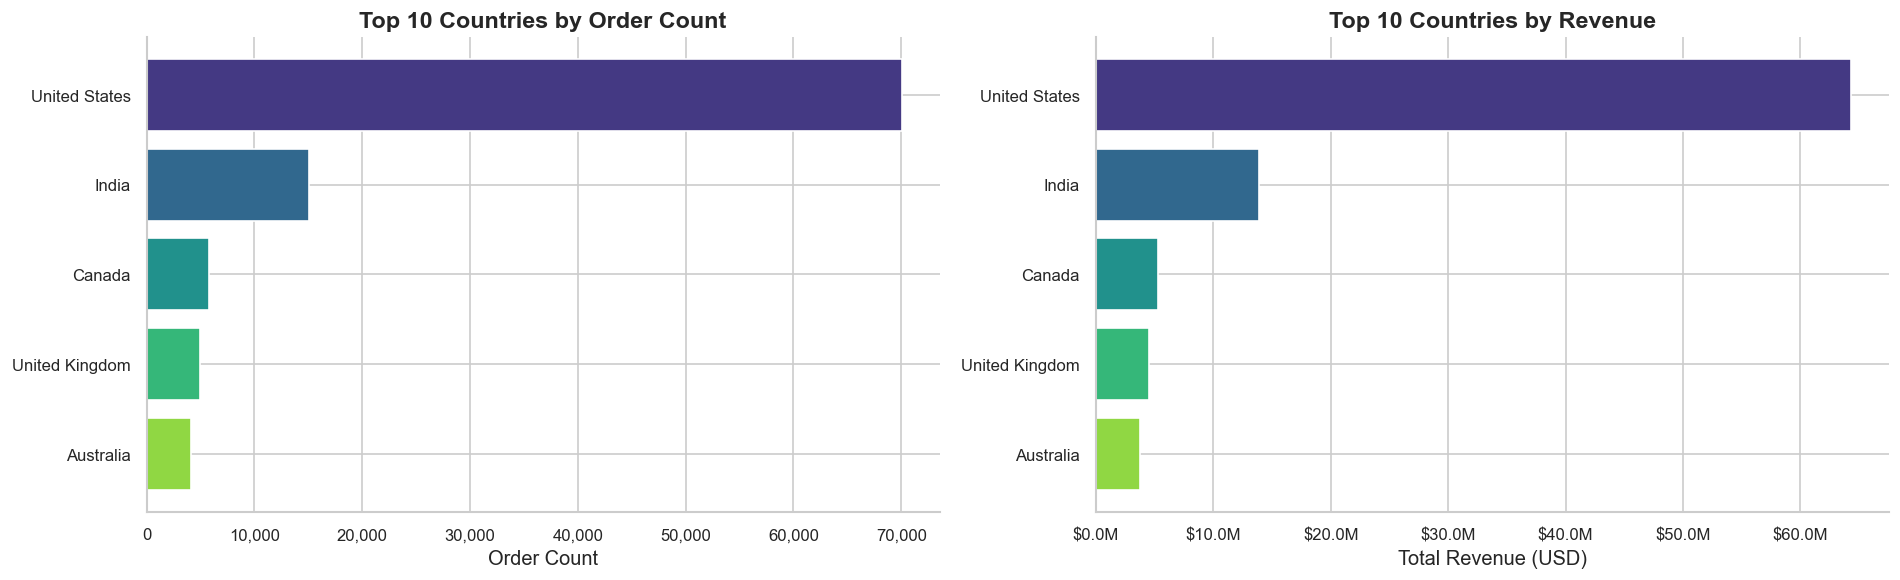

Saved: ../outputs/figures\geo_top_countries.png


In [21]:
# ── Top Countries chart ──
top_n = 10
top_countries = country_summary.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = sns.color_palette('viridis', len(top_countries))

# Orders
axes[0].barh(top_countries['Country'], top_countries['Order_Count'],
             color=palette, edgecolor='white')
axes[0].set_title(f'Top {top_n} Countries by Order Count', fontweight='bold')
axes[0].set_xlabel('Order Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].invert_yaxis()

# Revenue
axes[1].barh(top_countries['Country'], top_countries['Revenue'],
             color=palette, edgecolor='white')
axes[1].set_title(f'Top {top_n} Countries by Revenue', fontweight='bold')
axes[1].set_xlabel('Total Revenue (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].invert_yaxis()

sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'geo_top_countries.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


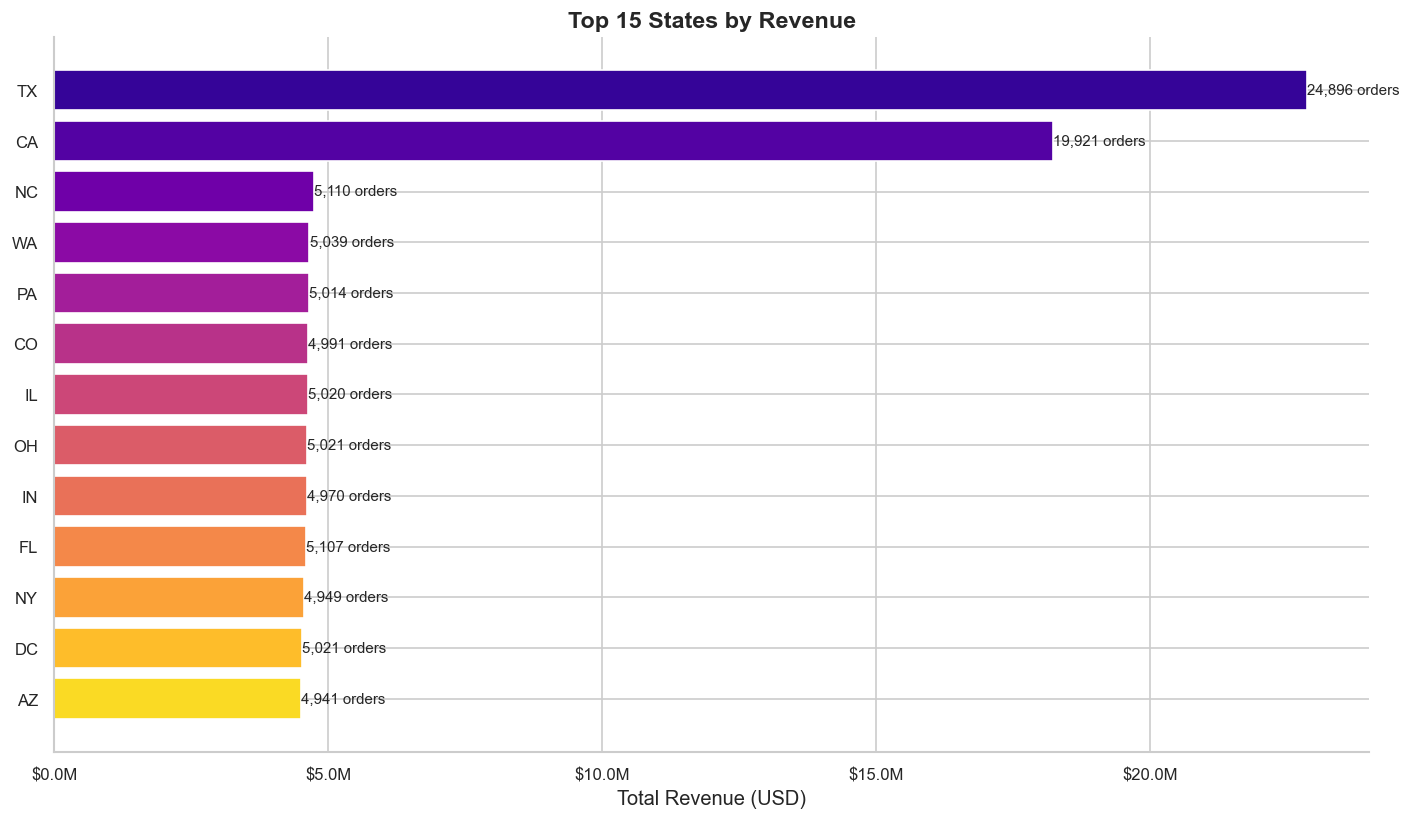

Saved: ../outputs/figures\geo_top_states.png


In [22]:
# ── Top 15 States ──
state_summary = (
    df.groupby('State')
    .agg(Order_Count=('OrderID','count'), Revenue=('TotalAmount','sum'))
    .sort_values('Revenue', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette('plasma', len(state_summary))
ax.barh(state_summary['State'], state_summary['Revenue'], color=palette, edgecolor='white')
for bar, count in zip(ax.patches, state_summary['Order_Count']):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{count:,} orders', va='center', fontsize=9)
ax.set_title('Top 15 States by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'geo_top_states.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


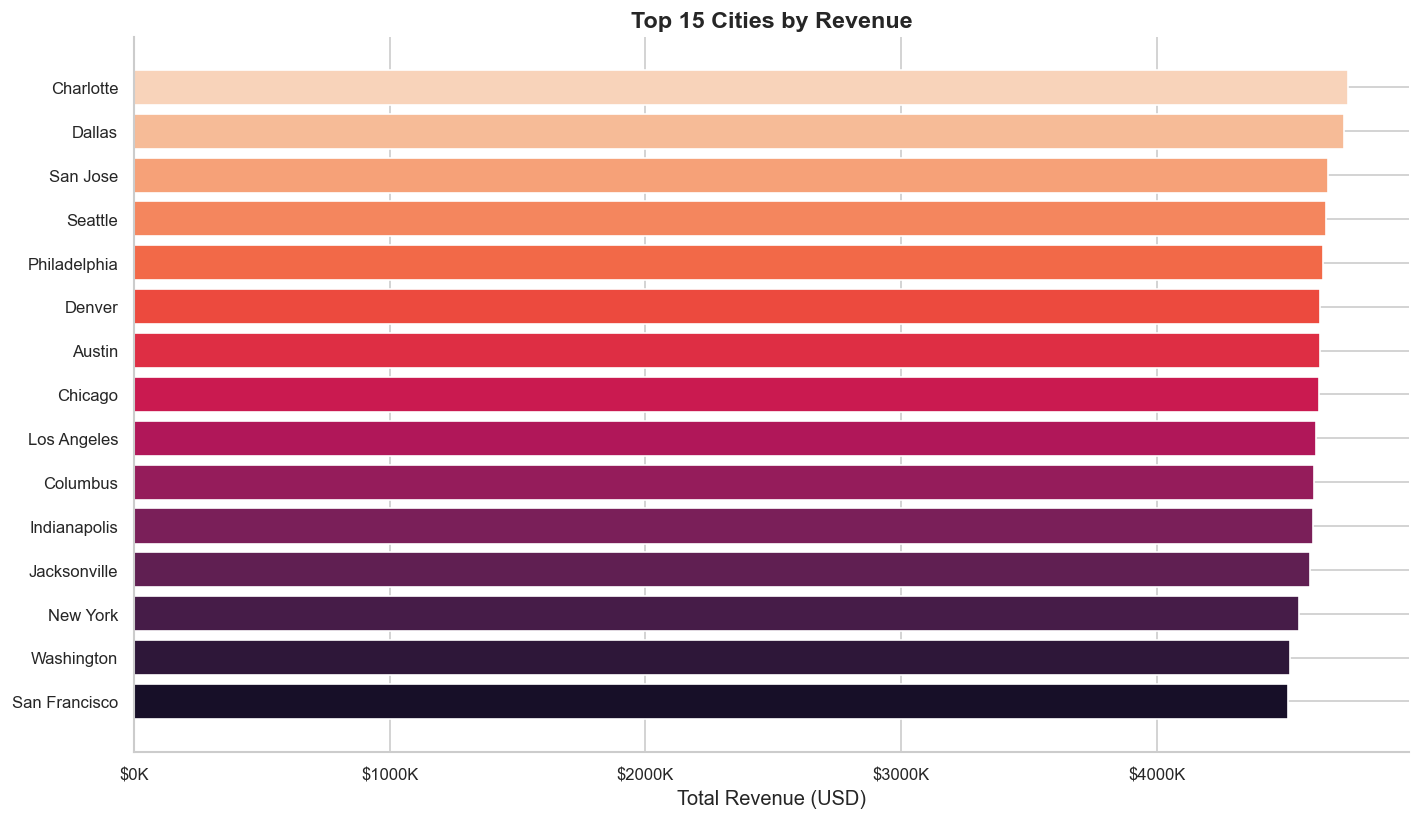

Saved: ../outputs/figures\geo_top_cities.png


In [23]:
# ── Top 15 Cities ──
city_summary = (
    df.groupby('City')
    .agg(Order_Count=('OrderID','count'), Revenue=('TotalAmount','sum'))
    .sort_values('Revenue', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette('rocket_r', len(city_summary))
ax.barh(city_summary['City'], city_summary['Revenue'], color=palette, edgecolor='white')
ax.set_title('Top 15 Cities by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'geo_top_cities.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


---
## 9. Payment Method Analysis


In [24]:
# ── Payment method summary ──
pay_summary = (
    df.groupby('PaymentMethod')
    .agg(
        Order_Count = ('OrderID',     'count'),
        Revenue     = ('TotalAmount', 'sum')
    )
    .sort_values('Revenue', ascending=False)
    .reset_index()
)
pay_summary['Order_Pct']   = (pay_summary['Order_Count'] / pay_summary['Order_Count'].sum() * 100).round(2)
pay_summary['Revenue_Pct'] = (pay_summary['Revenue'] / pay_summary['Revenue'].sum() * 100).round(2)

print("=== Payment Method Summary ===")
print(pay_summary.to_string(index=False))


=== Payment Method Summary ===
   PaymentMethod  Order_Count     Revenue  Order_Pct  Revenue_Pct
     Credit Card        35038 32122158.69      35.04        34.98
      Debit Card        20024 18538678.53      20.02        20.19
             UPI        15066 13896028.55      15.07        15.13
      Amazon Pay        15017 13697498.42      15.02        14.92
     Net Banking         9927  9055674.57       9.93         9.86
Cash on Delivery         4928  4515609.16       4.93         4.92


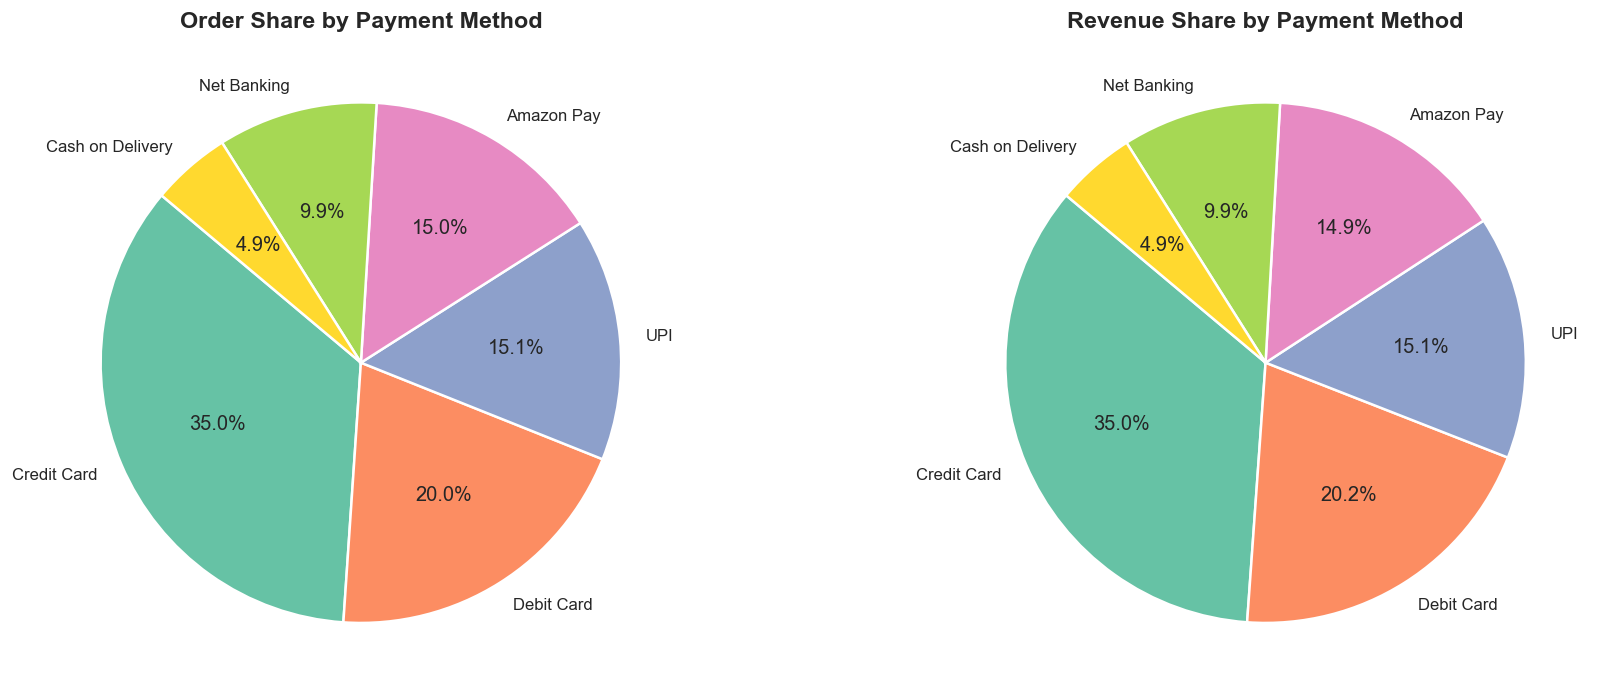

Saved: ../outputs/figures\payment_method_distribution.png


In [25]:
# ── Payment Method chart ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette('Set2', len(pay_summary))
wedge_props = {'linewidth': 1.5, 'edgecolor': 'white'}

# Order share
axes[0].pie(pay_summary['Order_Count'], labels=pay_summary['PaymentMethod'],
            autopct='%1.1f%%', colors=palette,
            wedgeprops=wedge_props, startangle=140)
axes[0].set_title('Order Share by Payment Method', fontweight='bold')

# Revenue share
axes[1].pie(pay_summary['Revenue'], labels=pay_summary['PaymentMethod'],
            autopct='%1.1f%%', colors=palette,
            wedgeprops=wedge_props, startangle=140)
axes[1].set_title('Revenue Share by Payment Method', fontweight='bold')

plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'payment_method_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


---
## 10. Seller Analysis


In [26]:
# ── Seller-level aggregation (including return/cancellation rates) ──
seller_summary = (
    df.groupby('SellerID')
    .agg(
        Order_Count       = ('OrderID',      'count'),
        Total_Quantity    = ('Quantity',      'sum'),
        Total_Revenue     = ('TotalAmount',   'sum'),
        Returned_Count    = ('OrderStatus',   lambda x: (x == 'Returned').sum()),
        Cancelled_Count   = ('OrderStatus',   lambda x: (x == 'Cancelled').sum()),
    )
    .reset_index()
)

seller_summary['Return_Rate']      = (seller_summary['Returned_Count']  / seller_summary['Order_Count'] * 100).round(2)
seller_summary['Cancellation_Rate'] = (seller_summary['Cancelled_Count'] / seller_summary['Order_Count'] * 100).round(2)
seller_summary = seller_summary.sort_values('Total_Revenue', ascending=False)

print(f"Total sellers: {len(seller_summary)}")
print()
print("=== Top 10 Sellers by Revenue ===")
print(seller_summary.head(10).to_string(index=False))


Total sellers: 1999

=== Top 10 Sellers by Revenue ===
 SellerID  Order_Count  Total_Quantity  Total_Revenue  Returned_Count  Cancelled_Count  Return_Rate  Cancellation_Rate
SELL00806           67             234       71283.67               6                1         8.96               1.49
SELL00440           61             197       71062.59               2                4         3.28               6.56
SELL01225           61             204       70785.92               1                3         1.64               4.92
SELL00709           69             223       70491.92               4                1         5.80               1.45
SELL00221           65             211       70446.50               1                3         1.54               4.62
SELL01122           67             217       69469.40               3                3         4.48               4.48
SELL00994           61             199       69400.06               1                4         1.64             

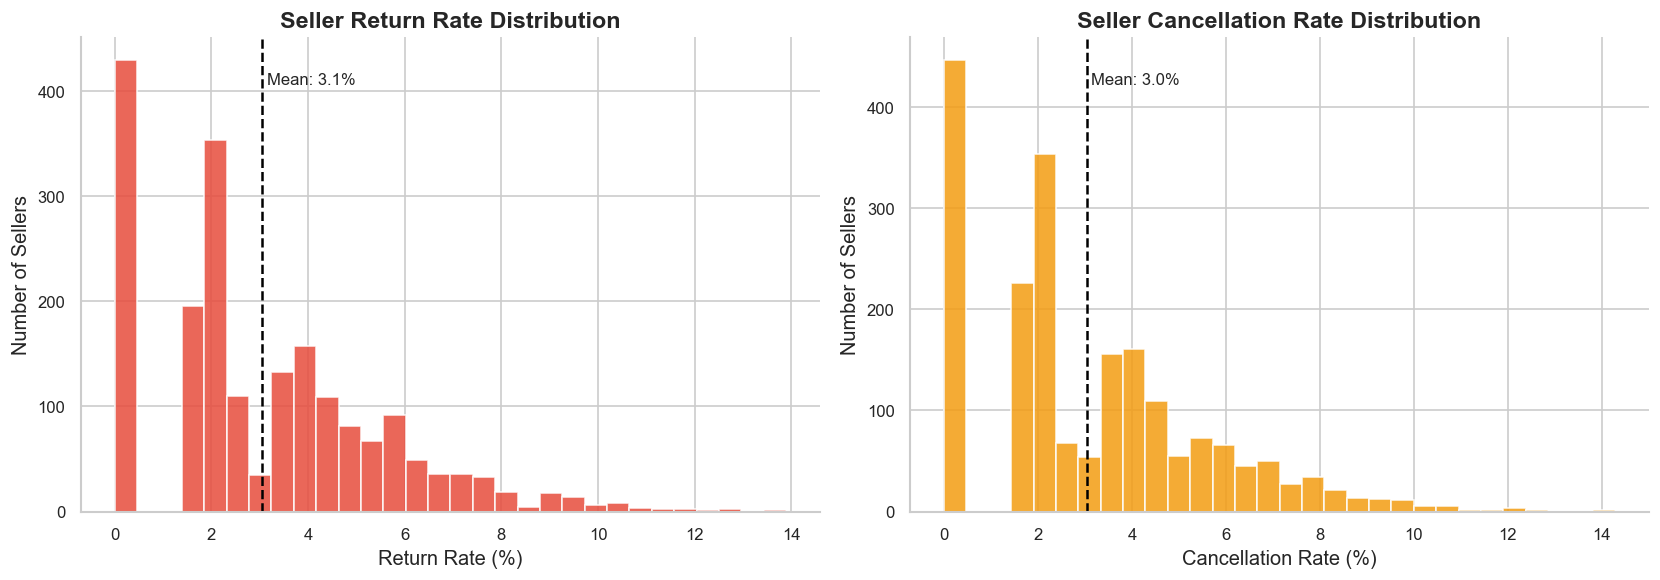

Saved: ../outputs/figures\seller_return_cancellation_rates.png


In [27]:
# ── Seller return/cancellation rate distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(seller_summary['Return_Rate'], bins=30, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_title('Seller Return Rate Distribution', fontweight='bold')
axes[0].set_xlabel('Return Rate (%)')
axes[0].set_ylabel('Number of Sellers')
mean_rr = seller_summary['Return_Rate'].mean()
axes[0].axvline(mean_rr, color='black', linestyle='--', linewidth=1.5)
axes[0].text(mean_rr + 0.1, axes[0].get_ylim()[1]*0.9, f'Mean: {mean_rr:.1f}%', fontsize=10)

axes[1].hist(seller_summary['Cancellation_Rate'], bins=30, color='#f39c12', edgecolor='white', alpha=0.85)
axes[1].set_title('Seller Cancellation Rate Distribution', fontweight='bold')
axes[1].set_xlabel('Cancellation Rate (%)')
axes[1].set_ylabel('Number of Sellers')
mean_cr = seller_summary['Cancellation_Rate'].mean()
axes[1].axvline(mean_cr, color='black', linestyle='--', linewidth=1.5)
axes[1].text(mean_cr + 0.1, axes[1].get_ylim()[1]*0.9, f'Mean: {mean_cr:.1f}%', fontsize=10)

sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'seller_return_cancellation_rates.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


---
## 11. Return & Cancellation Analysis

Identify groups with elevated return or cancellation rates for further investigation.

> ⚠️ A high return or cancellation rate does not necessarily indicate a problem — it may reflect product type, category norms, or customer expectations. These patterns warrant investigation, not immediate action.


In [28]:
# ── Overall rates ──
total_orders      = len(df)
total_returned    = (df['OrderStatus'] == 'Returned').sum()
total_cancelled   = (df['OrderStatus'] == 'Cancelled').sum()

print(f"Overall Return Rate      : {total_returned/total_orders*100:.2f}%  ({total_returned:,} orders)")
print(f"Overall Cancellation Rate: {total_cancelled/total_orders*100:.2f}%  ({total_cancelled:,} orders)")


Overall Return Rate      : 3.05%  (3,049 orders)
Overall Cancellation Rate: 3.03%  (3,028 orders)


In [29]:
def return_cancel_by(group_col):
    """Calculate return and cancellation rates by a grouping column."""
    grp = df.groupby(group_col).agg(
        Order_Count     = ('OrderID',     'count'),
        Returned        = ('OrderStatus', lambda x: (x == 'Returned').sum()),
        Cancelled       = ('OrderStatus', lambda x: (x == 'Cancelled').sum()),
    ).reset_index()
    grp['Return_Rate']      = (grp['Returned'] / grp['Order_Count'] * 100).round(2)
    grp['Cancellation_Rate'] = (grp['Cancelled'] / grp['Order_Count'] * 100).round(2)
    return grp.sort_values('Return_Rate', ascending=False)

# ── By Category ──
print("=== Return & Cancellation by Category ===")
cat_rc = return_cancel_by('Category')
print(cat_rc.to_string(index=False))


=== Return & Cancellation by Category ===
         Category  Order_Count  Returned  Cancelled  Return_Rate  Cancellation_Rate
   Home & Kitchen        16610       534        508         3.21               3.06
            Books        16752       523        500         3.12               2.98
Sports & Outdoors        16804       518        497         3.08               2.96
         Clothing        16439       504        467         3.07               2.84
     Toys & Games        16542       495        512         2.99               3.10
      Electronics        16853       475        544         2.82               3.23


In [30]:
# ── By Brand ──
print("=== Return & Cancellation by Brand ===")
brand_rc = return_cancel_by('Brand')
print(brand_rc.to_string(index=False))

# ── By Country ──
print("\n=== Return & Cancellation by Country ===")
country_rc = return_cancel_by('Country')
print(country_rc.to_string(index=False))


=== Return & Cancellation by Brand ===
     Brand  Order_Count  Returned  Cancelled  Return_Rate  Cancellation_Rate
    Zenith         9990       337        302         3.37               3.02
UrbanStyle         9854       313        283         3.18               2.87
  HomeEase         9795       310        293         3.16               2.99
      Apex         9937       305        310         3.07               3.12
  CoreTech        10127       303        323         2.99               3.19
 BrightLux         9907       295        316         2.98               3.19
    NexPro         9962       297        304         2.98               3.05
  KiddoFun        10077       296        306         2.94               3.04
  ReadMore        10204       300        302         2.94               2.96
   FitLife        10147       293        289         2.89               2.85

=== Return & Cancellation by Country ===
       Country  Order_Count  Returned  Cancelled  Return_Rate  Cancellat

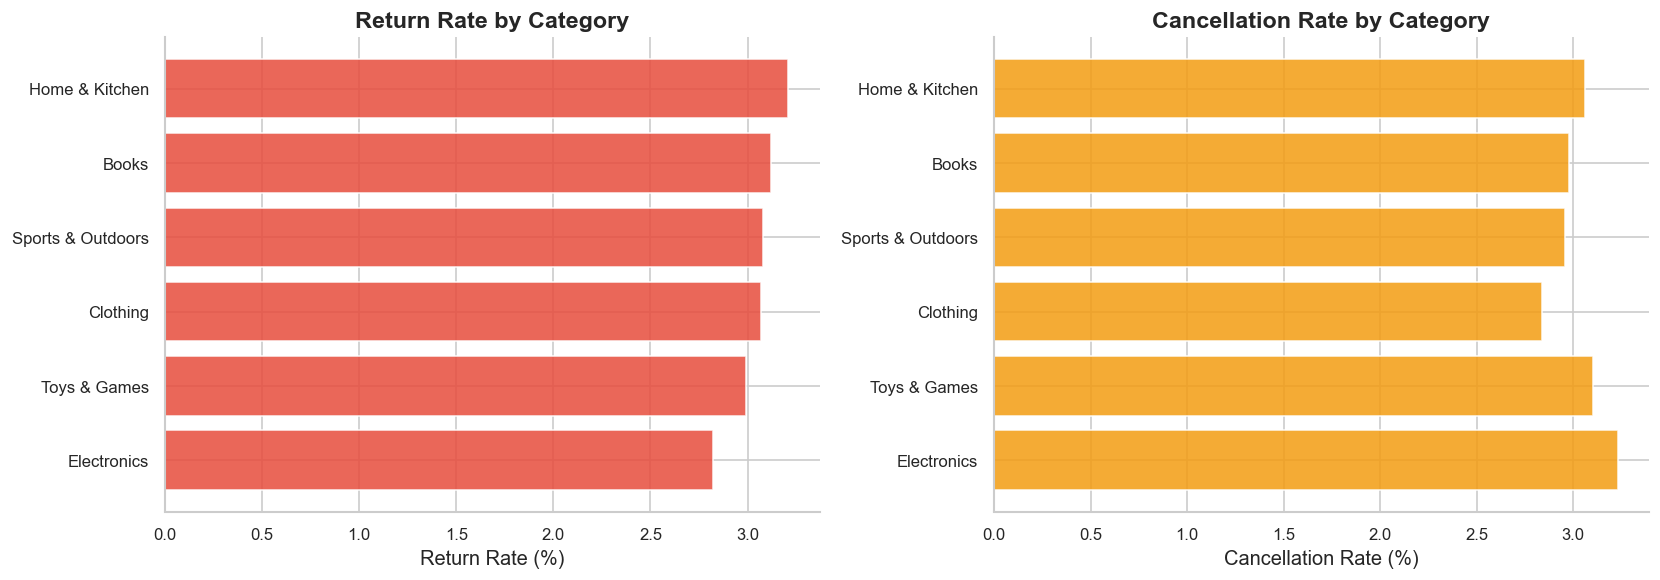

Saved: ../outputs/figures\return_cancellation_by_category.png


In [31]:
# ── Chart: Return & Cancellation by Category ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('tab10', len(cat_rc))

axes[0].barh(cat_rc['Category'], cat_rc['Return_Rate'],
             color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_title('Return Rate by Category', fontweight='bold')
axes[0].set_xlabel('Return Rate (%)')
axes[0].invert_yaxis()

axes[1].barh(cat_rc['Category'], cat_rc['Cancellation_Rate'],
             color='#f39c12', edgecolor='white', alpha=0.85)
axes[1].set_title('Cancellation Rate by Category', fontweight='bold')
axes[1].set_xlabel('Cancellation Rate (%)')
axes[1].invert_yaxis()

sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'return_cancellation_by_category.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


---
## 12. Numerical Distributions

Visualize the distribution of each key numerical field using histograms and boxplots.  
Outliers are **not removed** — this is EDA only.


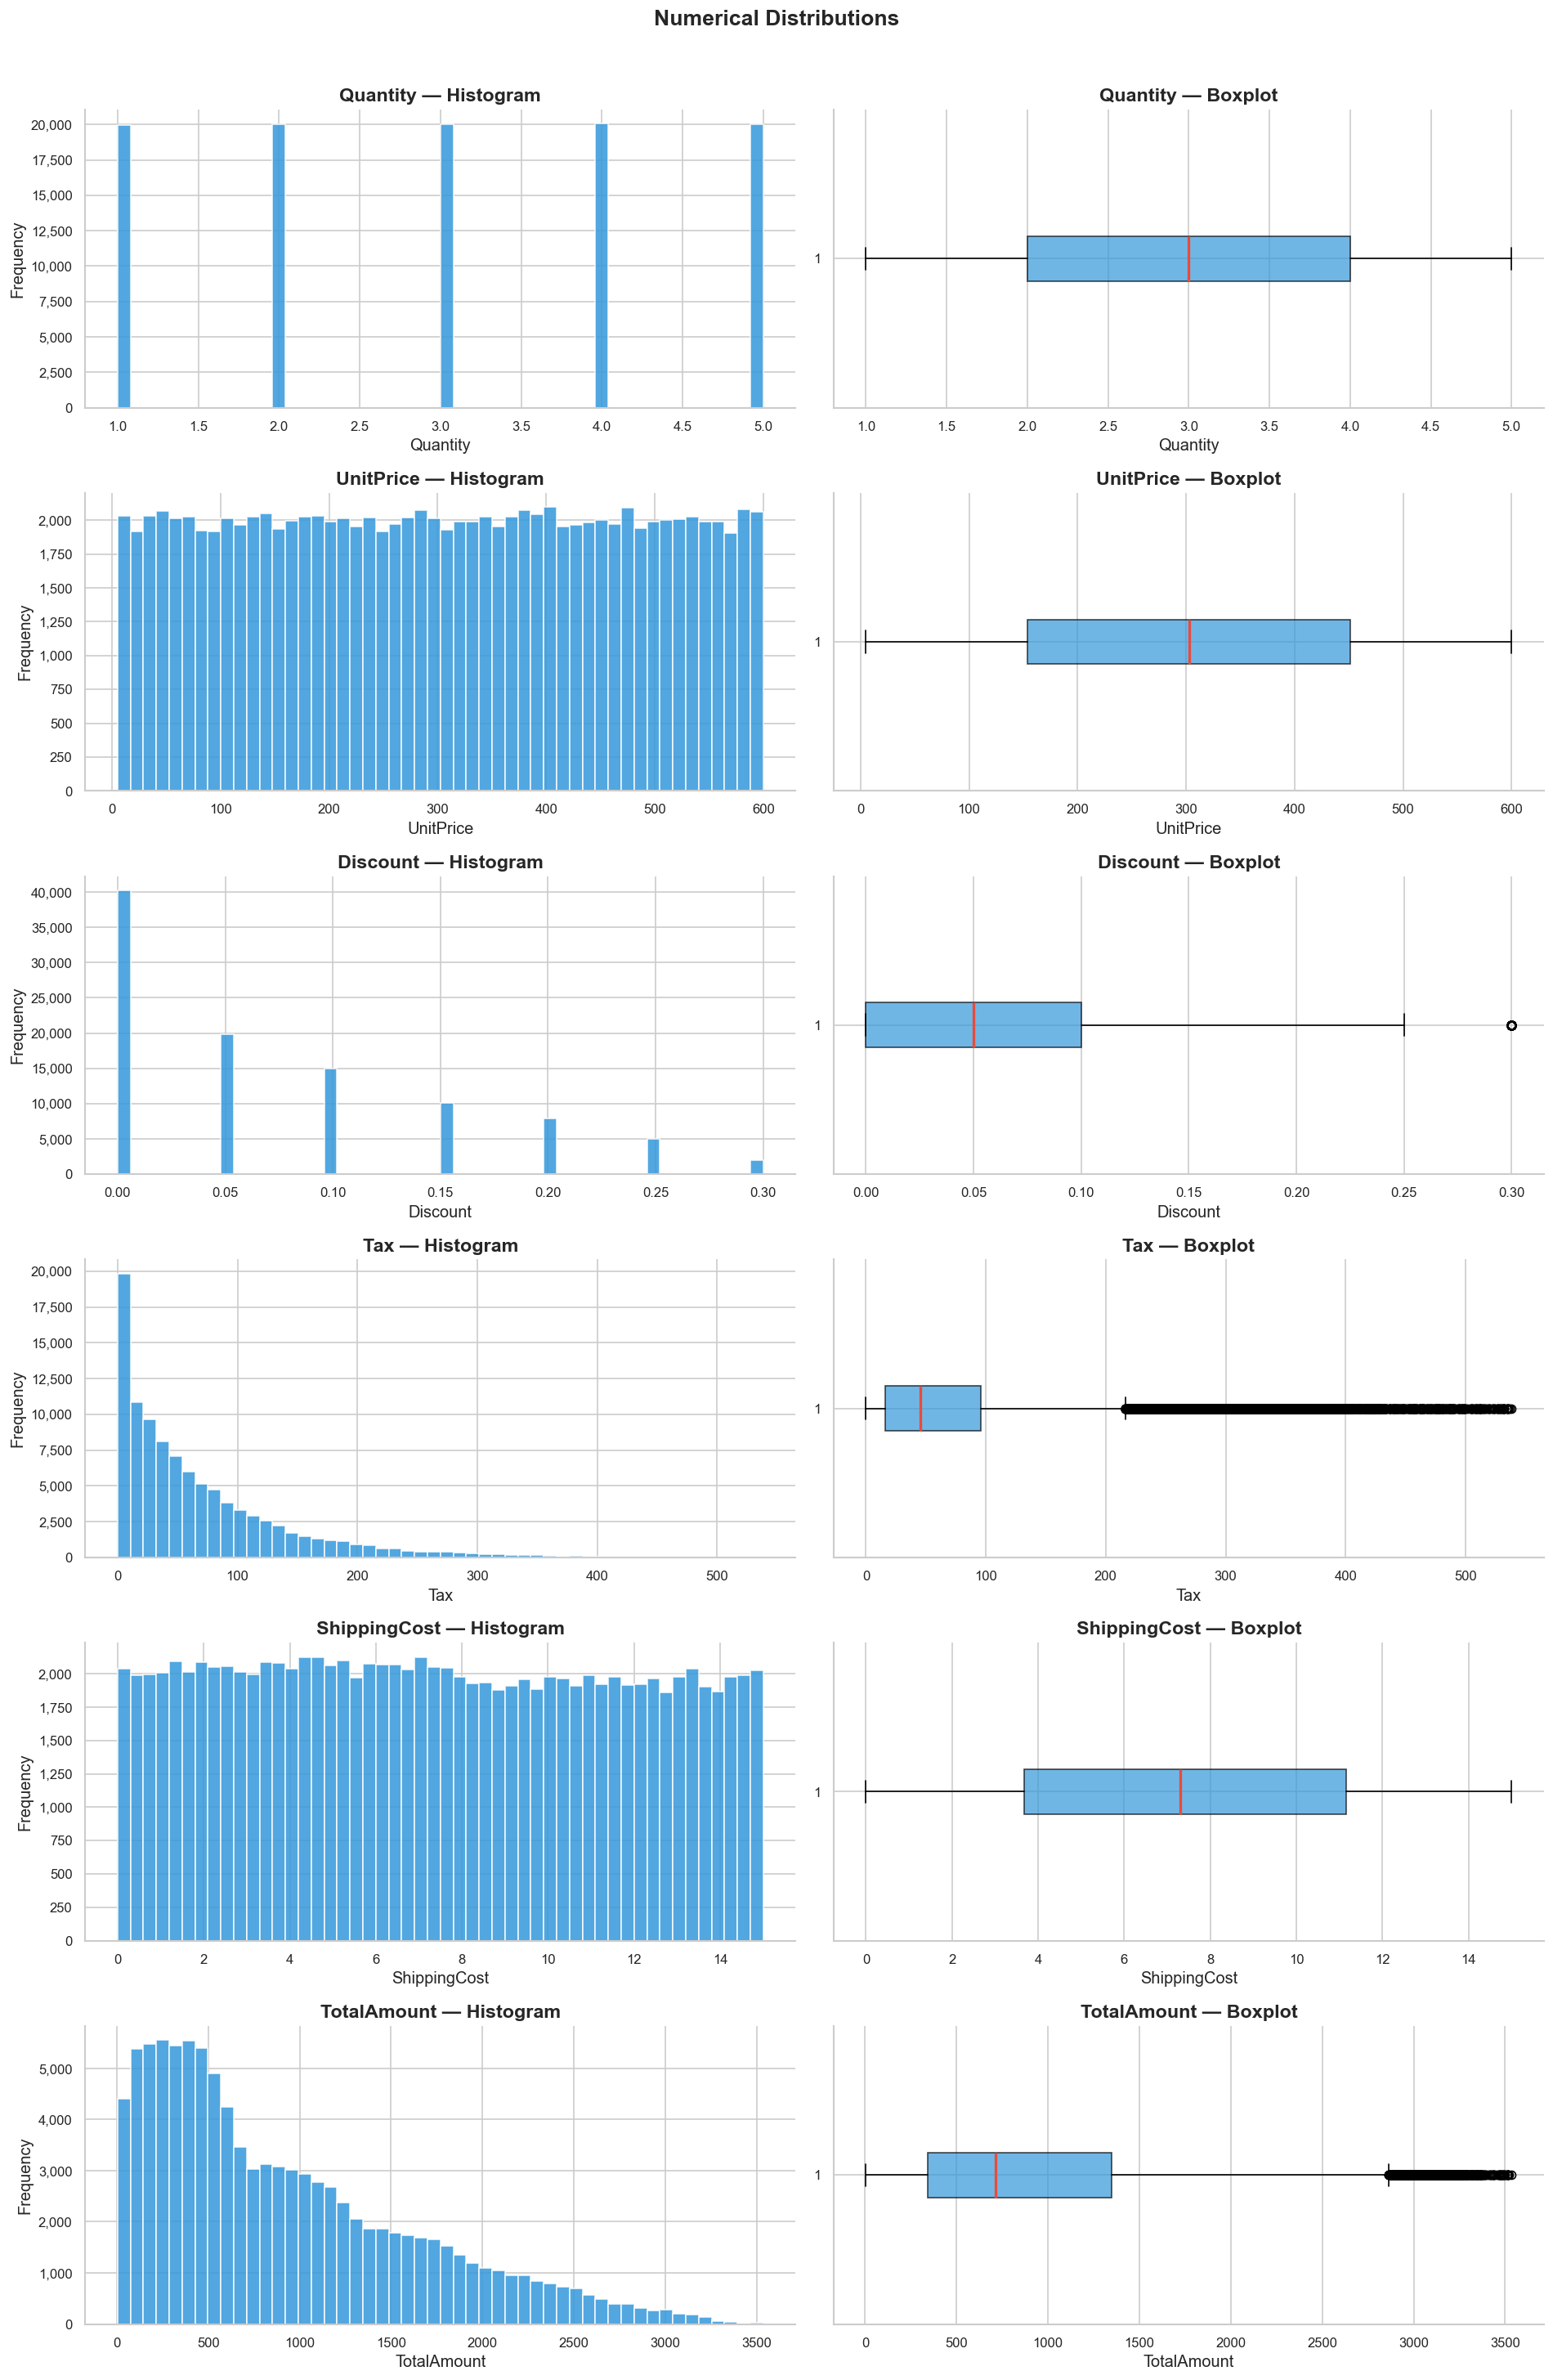

Saved: ../outputs/figures\numerical_distributions.png


In [32]:
numerical_cols = ['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(16, 4 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    # Histogram
    axes[i, 0].hist(df[col].dropna(), bins=50, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i, 0].set_title(f'{col} — Histogram', fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Boxplot
    axes[i, 1].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='#3498db', alpha=0.7),
                       medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i, 1].set_title(f'{col} — Boxplot', fontweight='bold')
    axes[i, 1].set_xlabel(col)

plt.suptitle('Numerical Distributions', fontsize=16, fontweight='bold', y=1.01)
sns.despine()
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'numerical_distributions.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


---
## 13. Correlation Analysis

Examine correlations between numerical fields.

> ⚠️ **Important:** Correlation is not causation.  
> Note that `TotalAmount` is likely a mathematical function of `Quantity`, `UnitPrice`, `Discount`, `Tax`, and `ShippingCost` — high correlations between these fields may reflect formula relationships rather than independent statistical associations.


In [33]:
# ── Correlation matrix ──
corr_cols = ['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']
corr_matrix = df[corr_cols].corr()

print("=== Correlation Matrix ===")
print(corr_matrix.round(4))


=== Correlation Matrix ===
              Quantity  UnitPrice  Discount     Tax  ShippingCost  TotalAmount
Quantity        1.0000     0.0044   -0.0004  0.4379        0.0200       0.5949
UnitPrice       0.0044     1.0000    0.0062  0.5269        0.0458       0.7158
Discount       -0.0004     0.0062    1.0000 -0.0776        0.0003      -0.1081
Tax             0.4379     0.5269   -0.0776  1.0000        0.0235       0.7794
ShippingCost    0.0200     0.0458    0.0003  0.0235        1.0000       0.0393
TotalAmount     0.5949     0.7158   -0.1081  0.7794        0.0393       1.0000


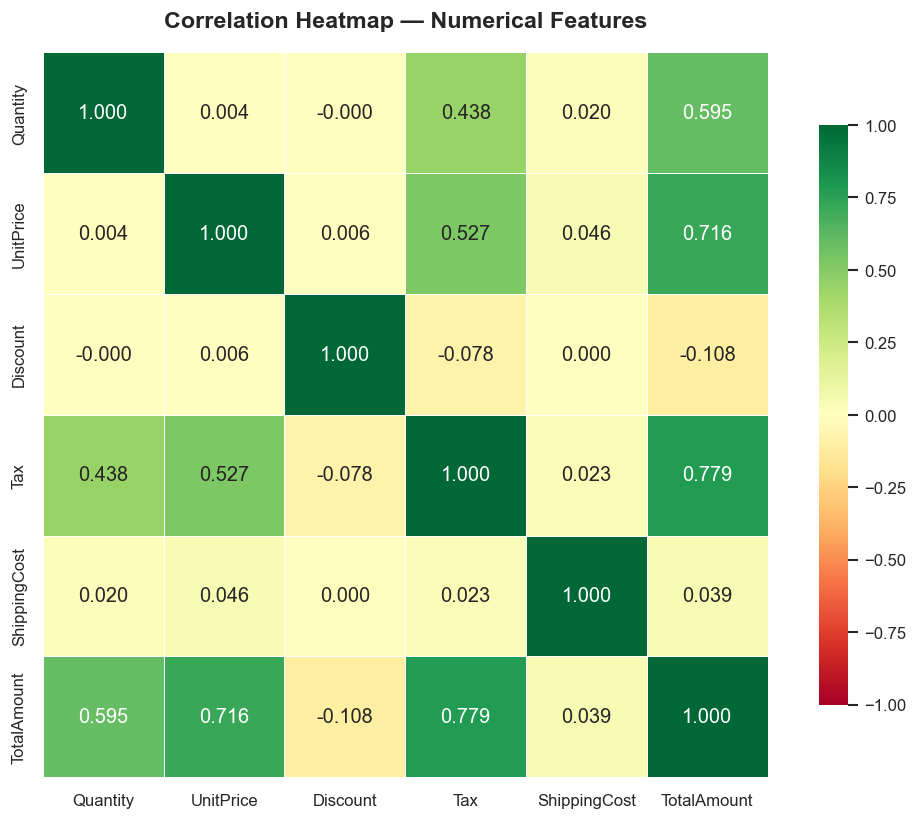

Saved: ../outputs/figures\numerical_correlation_heatmap.png


In [34]:
# ── Heatmap ──
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False   # show full matrix

heatmap = sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=-1, vmax=1, linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'numerical_correlation_heatmap.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


---
## 14. Key EDA Findings

The findings below are derived **only** from the actual data computed in this notebook. No values are invented.


In [35]:
# ── Print consolidated EDA findings ──

print("=" * 65)
print("     KEY EDA FINDINGS — RetailMind AI")
print("=" * 65)

# -- Order Status
delivered_pct = (df['OrderStatus'] == 'Delivered').sum() / len(df) * 100
returned_pct  = (df['OrderStatus'] == 'Returned').sum()  / len(df) * 100
cancelled_pct = (df['OrderStatus'] == 'Cancelled').sum() / len(df) * 100
shipped_pct   = (df['OrderStatus'] == 'Shipped').sum()   / len(df) * 100
pending_pct   = (df['OrderStatus'] == 'Pending').sum()   / len(df) * 100

print(f"\n[ORDER STATUS]")
print(f"  Delivered: {delivered_pct:.1f}% | Shipped: {shipped_pct:.1f}%")
print(f"  Pending:   {pending_pct:.1f}% | Returned: {returned_pct:.1f}%")
print(f"  Cancelled: {cancelled_pct:.1f}%")
print(f"  → Approximately {returned_pct + cancelled_pct:.1f}% of orders did not complete successfully.")

# -- Trends
print(f"\n[SALES TRENDS]")
print(f"  Date range: 2020-01-01 to 2024-12-29 (5 years)")
orders_per_year = df.groupby('Year')['OrderID'].count()
rev_per_year    = df.groupby('Year')['TotalAmount'].sum()
for yr in sorted(orders_per_year.index):
    print(f"  {yr}: {orders_per_year[yr]:,} orders | ${rev_per_year[yr]/1e6:.2f}M revenue")

# -- Products
print(f"\n[PRODUCTS]")
print(f"  Total distinct products: {df['ProductID'].nunique()}")
print(f"  Top revenue product: {product_summary.iloc[0]['ProductName']} (${product_summary.iloc[0]['Total_Revenue']/1e3:.1f}K)")
print(f"  Top volume product : {product_summary.nlargest(1,'Total_Quantity').iloc[0]['ProductName']}")

# -- Category
print(f"\n[CATEGORIES]")
top_cat = cat_summary.iloc[0]
print(f"  Top category by revenue: {top_cat['Category']} (${top_cat['Total_Revenue']/1e6:.2f}M, {top_cat['Revenue_Pct']:.1f}%)")
print(f"  Categories are roughly evenly distributed in order volume.")

# -- Brand
print(f"\n[BRANDS]")
top_brand = brand_summary.iloc[0]
print(f"  Top brand by revenue: {top_brand['Brand']} (${top_brand['Total_Revenue']/1e6:.2f}M, {top_brand['Revenue_Pct']:.1f}%)")
print(f"  Brands appear to have broadly similar market share.")

# -- Customers
print(f"\n[CUSTOMERS]")
print(f"  Unique customers: {df['CustomerID'].nunique():,}")
median_cust_orders = customer_summary['Order_Count'].median()
mean_cust_orders   = customer_summary['Order_Count'].mean()
print(f"  Median orders per customer: {median_cust_orders:.0f}")
print(f"  Mean orders per customer  : {mean_cust_orders:.2f}")
print(f"  Most customers appear to be repeat buyers.")

# -- Geography
top_country = country_summary.iloc[0]
print(f"\n[GEOGRAPHY]")
print(f"  Top country: {top_country['Country']} ({top_country['Order_Count']:,} orders, {top_country['Revenue_Pct']:.1f}% of revenue)")
print(f"  5 countries in dataset: United States, India, Canada, United Kingdom, Australia")

# -- Payment
top_pay = pay_summary.iloc[0]
print(f"\n[PAYMENT METHODS]")
print(f"  Most common: {top_pay['PaymentMethod']} ({top_pay['Order_Pct']:.1f}% of orders)")

# -- Returns
print(f"\n[RETURNS & CANCELLATIONS]")
print(f"  Overall return rate      : {returned_pct:.2f}%")
print(f"  Overall cancellation rate: {cancelled_pct:.2f}%")
print(f"  Return/cancellation rates appear consistent across categories.")
print(f"  No single category or brand shows a dramatic spike — warrants continued monitoring.")

print()
print("=" * 65)
print("No values invented. All figures derived from actual dataset.")
print("=" * 65)


     KEY EDA FINDINGS — RetailMind AI

[ORDER STATUS]
  Delivered: 74.6% | Shipped: 15.2%
  Pending:   4.1% | Returned: 3.0%
  Cancelled: 3.0%
  → Approximately 6.1% of orders did not complete successfully.

[SALES TRENDS]
  Date range: 2020-01-01 to 2024-12-29 (5 years)
  2020: 20,066 orders | $18.53M revenue
  2021: 19,890 orders | $18.25M revenue
  2022: 20,078 orders | $18.37M revenue
  2023: 20,096 orders | $18.51M revenue
  2024: 19,870 orders | $18.17M revenue

[PRODUCTS]
  Total distinct products: 50
  Top revenue product: Desk Organizer ($58.1K)
  Top volume product : 4K Monitor

[CATEGORIES]
  Top category by revenue: Electronics ($15.58M, 17.0%)
  Categories are roughly evenly distributed in order volume.

[BRANDS]
  Top brand by revenue: CoreTech ($9.34M, 10.2%)
  Brands appear to have broadly similar market share.

[CUSTOMERS]
  Unique customers: 43,233
  Median orders per customer: 2
  Mean orders per customer  : 2.31
  Most customers appear to be repeat buyers.

[GEOGRAP

---
## 15. Implications for ML (RetailMind AI)

Based on the EDA findings above, the following features appear promising for each ML module.

> ⚠️ No models are built here. This section only identifies potential features and analytical directions based on observed patterns.


In [36]:
print("=" * 65)
print("     IMPLICATIONS FOR ML — RetailMind AI")
print("=" * 65)

print("""
=== Demand Forecasting ===
  Useful features identified:
  • OrderDate (temporal: year, month, day-of-week)
  • ProductID, Category, Brand (product identity)
  • Quantity (target variable for forecasting)
  • TotalAmount (revenue target)
  • Country, State (geographic demand signals)
  • OrderStatus (completed vs. non-completed orders)
  
  Patterns relevant to forecasting:
  • 5-year temporal dataset (2020–2024) provides sufficient
    historical depth for lag features and rolling averages.
  • Monthly and yearly order patterns exist.
  • Multiple categories with roughly equal volume allows
    per-category model training.

=== Customer Segmentation ===
  Useful features identified:
  • CustomerID (grouping key)
  • OrderDate (recency calculation)
  • TotalAmount (monetary value per order)
  • Order count per customer (frequency)
  • Average order value
  
  Patterns relevant to segmentation:
  • 43,233 unique customers with varying order frequencies.
  • Customer-level aggregation (RFM) is feasible.
  • Geographic dimension (Country, State) adds segmentation depth.
  • Payment method preference is a potential behavioral feature.

=== Product Intelligence ===
  Useful features identified:
  • ProductID, ProductName, Category, Brand
  • Quantity, UnitPrice, TotalAmount, Discount
  • Return Rate per product (derived from OrderStatus)
  • Order Count per product
  
  Patterns relevant to product intelligence:
  • Only 50 unique products — suitable for fine-grained analysis.
  • Return and cancellation rates can be computed per product.
  • Category-level and brand-level aggregations are meaningful.

=== Revenue Intelligence ===
  Useful features identified:
  • TotalAmount (revenue)
  • Discount (pricing signal)
  • UnitPrice (price positioning)
  • PaymentMethod (transaction behaviour)
  • Country, Category (revenue segmentation)
  
  Patterns relevant to revenue intelligence:
  • Discount ranges from 0–30%, which may influence revenue.
  • 5 payment methods available — potential preference signals.
  • Revenue by geography, category, and brand is calculable.
  
  ⚠️ Note: TotalAmount may be a derived field (not independent),
  which must be accounted for when building revenue models.
""")

print("=" * 65)


     IMPLICATIONS FOR ML — RetailMind AI

=== Demand Forecasting ===
  Useful features identified:
  • OrderDate (temporal: year, month, day-of-week)
  • ProductID, Category, Brand (product identity)
  • Quantity (target variable for forecasting)
  • TotalAmount (revenue target)
  • Country, State (geographic demand signals)
  • OrderStatus (completed vs. non-completed orders)

  Patterns relevant to forecasting:
  • 5-year temporal dataset (2020–2024) provides sufficient
    historical depth for lag features and rolling averages.
  • Monthly and yearly order patterns exist.
  • Multiple categories with roughly equal volume allows
    per-category model training.

=== Customer Segmentation ===
  Useful features identified:
  • CustomerID (grouping key)
  • OrderDate (recency calculation)
  • TotalAmount (monetary value per order)
  • Order count per customer (frequency)
  • Average order value

  Patterns relevant to segmentation:
  • 43,233 unique customers with varying order frequenc

---
## 16. Inventory Data Check

Explicitly check whether the current dataset contains inventory-level information needed for inventory optimization.


In [37]:
# ── List actual columns in the dataset ──
actual_columns = df.columns.tolist()

inventory_fields = {
    'StockLevel'         : 'Current inventory quantity on hand',
    'ReorderPoint'       : 'Stock level at which reorder is triggered',
    'SafetyStock'        : 'Buffer stock to prevent stockouts',
    'LeadTime'           : 'Supplier lead time (days)',
    'SupplierID'         : 'Supplier identity for procurement',
    'CurrentInventory'   : 'Current available inventory',
    'WarehouseID'        : 'Warehouse or storage location',
    'RestockDate'        : 'Date of last or next restock',
}

print("=== Inventory Field Check ===")
print(f"\nActual dataset columns: {actual_columns}")
print()

found_any = False
for field, desc in inventory_fields.items():
    present = any(field.lower() in col.lower() for col in actual_columns)
    status  = "✅ PRESENT" if present else "❌ ABSENT"
    if present:
        found_any = True
    print(f"  {status} | {field:22s} | {desc}")

print()
if not found_any:
    print("=" * 65)
    print("CONCLUSION:")
    print()
    print("  TRUE INVENTORY OPTIMIZATION CANNOT BE DIRECTLY IMPLEMENTED")
    print("  USING THE CURRENT DATASET ALONE.")
    print()
    print("  The Amazon.csv dataset contains transactional order records")
    print("  only. It does NOT include:")
    print("  • Current stock levels")
    print("  • Reorder points")
    print("  • Safety stock thresholds")
    print("  • Supplier lead times")
    print("  • Warehouse or supplier inventory data")
    print()
    print("  What IS possible with the current data:")
    print("  • Demand estimation (historical order quantities)")
    print("  • Demand forecasting (time-series on Quantity)")
    print("  • Sell-through rate approximation (by product/category)")
    print("  • Identifying high-velocity vs. low-velocity products")
    print()
    print("  To build true inventory optimization, an additional")
    print("  inventory/supplier dataset would need to be integrated.")
    print("=" * 65)
else:
    print("Some inventory-related fields were found. Review the list above.")


=== Inventory Field Check ===

Actual dataset columns: ['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus', 'City', 'State', 'Country', 'SellerID', 'Year', 'Month', 'MonthName']

  ❌ ABSENT | StockLevel             | Current inventory quantity on hand
  ❌ ABSENT | ReorderPoint           | Stock level at which reorder is triggered
  ❌ ABSENT | SafetyStock            | Buffer stock to prevent stockouts
  ❌ ABSENT | LeadTime               | Supplier lead time (days)
  ❌ ABSENT | SupplierID             | Supplier identity for procurement
  ❌ ABSENT | CurrentInventory       | Current available inventory
  ❌ ABSENT | WarehouseID            | Warehouse or storage location
  ❌ ABSENT | RestockDate            | Date of last or next restock

CONCLUSION:

  TRUE INVENTORY OPTIMIZATION CANNOT BE DIRECTLY IMPLEMENTED
  USING THE CURRENT DATASE